# 电商用户价值分层

## 一、项目背景与目标

大家常用的传统RFM模型，主要是看最近一次购买时间、买了多少次和花了多少钱。但在实际的电商运营中，这套模型其实有点滞后和死板。

主要存在两个问题：
1.  **识别不了高潜水的观望者**：有些用户天天来逛，停留时间很长，但就是不花钱。传统模型会把他们归为“低价值用户”，但实际上他们可能是没找到心仪的商品，转化潜力巨大。
2.  **忽略了购买力背景**：一个月薪5万的用户买了1000块钱的东西，和一个月薪5000的用户买了1000块钱的东西，背后的价值完全不同。传统模型一刀切，容易把“有矿但没花”的土豪和“咬牙支持”的铁粉混为一谈。

所以，这次项目的目标很明确：**在RFM的基础上，引入用户意向度、活跃度和收入背景这几个修正因子，把用户分层做得更细、更准。** 最终目的是为运营提供清晰的行动指南，让大家发的每一张券、打的每一个电话，都能花在刀刃上。

---

## 二、数据概览与质量检查

这次分析用到的数据质量还不错，省去了很多清洗的麻烦。

*   **数据规模**：总共看了1000条用户记录，每个用户都有14个字段的信息，既包含了传统的消费数据，也包含了像“网站停留时间”、“浏览页数”这样的行为数据，还有年龄、收入等基础画像。
*   **数据质量**：所有字段都没有缺失值，这点很难得，但是这也是真实业务中不可能出现的情况。年龄范围也正常（18-64岁）。

---

## 三、指标体系构建

为了把用户看透，我们这次构建了一个复合型的打分体系：

1.  **基础RFM指标（R/F/M）**：
    *   **R (近度)**：用“最近一次登录距今几天”来衡量。登录越勤快，得分越高。
    *   **F (频次)**：就是购买次数，买得越多越忠诚。
    *   **M (金额)**：历史总消费，这是衡量“钱包份额”的核心。

2.  **意向度指标 —— 重点引入**
    *   **这是本次模型的核心创新**。我们想知道用户到底想不想买。
    *   **公式**：`I_Score = 停留时长得分 × 0.5 + 浏览页数得分 × 0.5`。
    *   **逻辑**：如果一个用户天天在网站上逛，看了很多页，哪怕他现在没下单，也说明他对平台的内容或商品感兴趣，这就是“高潜”信号。

3.  **转化摩擦系数**
    *   这个指标很有意思，用来衡量用户的纠结程度。
    *   **公式**：`摩擦系数 = 浏览页数 / (购买次数 + 1)`。
    *   **解读**：如果这个系数很高，说明用户看了几十页才买一次，甚至一次都没买。这类用户要么是在“货比三家”，要么是选择困难症，是运营重点“推一把”的对象。

4.  **活跃连接度**
    *   这个指标修正了传统的“是否订阅”。我们更看重**“行为忠诚”而非“名义忠诚”**。
    *   **高（3分）**：既订阅了，最近7天还登录了。这才是真·死忠粉。
    *   **中（2分）**：没订阅，但最近7天天天来。这是“闷骚型”活跃用户，虽然没绑关系，但身体很诚实。
    *   **低（1分）**：订阅了但30天没来（僵尸订阅），或者压根不活跃。

5.  **购买力背景**
    *   根据用户收入，划分为低、中、高三个等级。
    *   **注意**：这个指标不计入总分，而是作为分层后的**修正标签**。因为它能帮我们回答一个关键问题：同样是消费1000块，对这个用户来说是撒撒水还是掏空口袋？

---

## 四、探索性数据分析

在做模型之前，我们先翻了一遍数据，发现两个反直觉的现象：

1.  **只看不买是普遍现象**：
    *   我们本以为逛得久的人应该买得多，但数据告诉我们：**网站停留时间与购买频率的相关系数接近于0**。
    *   这说明平台里存在着大量的观光团。他们贡献了流量和活跃度，但没贡献GMV。这也反向证明了，我们引入**意向度指标是非常必要的**，因为传统RFM模型根本看不见这群人。

2.  **有钱人不一定花钱**：
    *   我们把高收入群体拎出来一看，发现其中有**超过一半（54.1%）的人消费低于平均水平**。
    *   这帮人是典型的潜力股：钱包鼓鼓，但在我们这还没怎么掏钱。**他们是本次精准营销的重点唤醒对象**。

---

## 五、RFM-I模型构建

为了让不同维度的数据能放在一起比较，我们先对R、F、M、I做了归一化处理（统一换算成0-100分）。

*   **基础RFM得分**：
    *   `RFM_Score = R×0.2 + F×0.3 + M×0.5`
    *   **为什么这么设权重？** 在电商里，掏多少钱永远是第一位的，频次代表粘性排第二，最近登录虽然重要，但只是个活跃度参考，所以权重最低。

*   **最终综合得分**：
    *   `Final_Score = RFM_Score × (1 + I_Weight)`
    *   **逻辑**：把意向度作为放大器。如果一个用户虽然过去花钱不多，但最近意向度极高，他的最终得分会被拉高，从而进入我们的高潜观察名单。

---

## 六、用户分层与画像
| 用户分层 | 用户数 | 平均消费 | 平均购买频率 | 平均意向分 | 平均收入 | 占比(%) |
|----------|--------|----------|--------------|------------|----------|---------|
| 一般用户 | 443 | 2368 | 5.17 | 48.80 | 84306 | 44.3% |
| 一般发展用户 | 81 | 1118 | 6.43 | 49.84 | 87107 | 8.1% |
| 重要挽留用户 | 67 | 4134 | 2.57 | 46.53 | 59699 | 6.7% |
| 高潜流失客 | 64 | 3991 | 4.92 | 44.09 | 121985 | 6.4% |
| 低价值用户 | 50 | 1037 | 1.68 | 42.79 | 94735 | 5.0% |
| 重要发展用户 | 48 | 3874 | 1.62 | 48.91 | 81231 | 4.8% |
| 核心VIP | 23 | 4171 | 8.17 | 71.09 | 59382 | 2.3% |
| 隐形活跃者 | 34 | 2757 | 1.32 | 78.00 | 36273 | 3.4% |
| 纠结土豪 | 6 | 1157 | 1.67 | 78.86 | 125519 | 0.6% |

**典型用户画像与运营策略：**
这部分跳到最后面可以看到精细化运营策略。

## 七、ROI测算

### 方案A：传统RFM策略

- **目标用户**：RFM 综合得分排名前 20% 的用户，共 200 人
- **成本**：200 人 × 10 元 = 2,000 元
- **边际收益（增量收入）**：  
  边际提升 10 个百分点，即多转化 200 × 10% = 20 人  
  20 人 × 104 元 = 2,081 元
- **边际ROI** = (边际收益 - 成本) / 成本 = (2,081 - 2,000) / 2,000 = **4.0%**

> 虽然ROI为正，但问题在于：发给高RFM用户的券，很大部分属于无效补贴——他们本来就要买，券只是挤占了原本的自然购买，实际带来的增量有限。

### 方案B：优化RFM-I策略

- **目标用户**：  
  - 核心用户（如核心VIP等）：70 人  
  - 新挖掘的潜力用户（纠结土豪、高潜流失客等）：89 人  
  - **合计**：159 人
- **成本**：159 人 × 10 元 = 1,590 元（预算使用率仅 15.9%，还有大量预算可灵活调配）
- **边际收益（增量收入）**：
  - 核心用户边际提升 5 个百分点：多转化 70 × 5% = 3.5 人 ≈ 3.5 人  
  - 潜力用户边际提升 19 个百分点：多转化 89 × 19% = 16.91 人 ≈ 16.9 人  
  - 合计多转化 20.41 人  
  - 增量收入 = 20.41 × 104 元 ≈ **2,123 元**
- **边际ROI** = (2,123 - 1,590) / 1,590 = **33.5%**

### 结论

- **方案B的边际ROI（33.5%）远高于方案A（4.0%）**，说明新模型找到的这群潜力用户虽然人数不多，但他们对营销刺激的敏感度极高，**每一块钱营销费用能撬动更多的增量交易**。
- 方案B只用了不到 16% 的预算就实现了比方案A更高的增量收益，剩余预算还可以继续投入到其他高潜力人群中，**整体资金使用效率大幅提升**。
- 更重要的是，新模型帮助我们避免了把钱浪费在本来就打算买的用户身上，实现了精准的增量挖掘。
---

## 八、总结与展望

这次项目最大的价值，不是创造了一套复杂的数学公式，而是**帮我们重新理解了用户价值**。

1.  **指标重构**：我们不再只看用户花了多少钱，也开始看用户花了多少时间和有多少预算。这让我们发现了隐形活跃者和纠结土豪这样传统模型无法识别的群体。
2.  **策略落地**：分层不是目的，目的是让运营动作更有针对性。对VIP要维稳，对纠结土豪要种草，隐形活跃者要搞裂变。

**接下来可以怎么玩？**

*   **动态监控**：可以给这群人建立流失预警模型，一旦发现纠结土豪的意向度下降，或者高潜流失客的登录间隔变长，系统自动触发挽回动作。
*   **算法介入**：尝试用机器学习算法，针对不同分层的人群，自动匹配最优的优惠券面额或推送文案，实现千人千面的自动化营销。

In [2]:
# 1. 环境准备与库导入
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
# 2. 请根据实际修改文件路径
input_path = 'user_personalized_features.csv'
output_dir = 'rfm_analysis'

In [4]:
# 3. 数据加载与预处理函数
def load_and_preprocess(filepath):
    """数据加载与预处理"""
    df = pd.read_csv(filepath, sep=',', encoding='utf-8', usecols=lambda col: col not in ['Unnamed: 0'])
    
    # 数据质量检查
    print("=" * 60)
    print("第一阶段：数据质量检查")
    print("=" * 60)
    print(f"数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"缺失值: {df.isnull().sum().sum()}") 
    
    # 异常值处理
    age_outliers = df[(df['Age'] < 10) | (df['Age'] > 100)].shape[0]
    print(f"年龄异常值: {age_outliers}")    
    return df

# 执行数据加载
df = load_and_preprocess(input_path)
df.head()

第一阶段：数据质量检查
数据规模: 1000 行 x 14 列
缺失值: 0
年龄异常值: 0


,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


In [5]:
# 4. 特征工程：构建优化指标
def feature_engineering(df):
    """特征工程：构建RFM-I模型所需的所有指标"""
    
    print("\n" + "=" * 60)
    print("第二阶段：特征工程 - 构建优化指标")
    print("=" * 60)
    
    # 1. 基础RFM指标已在数据中
    
    # 2. I (Intent - 意向深度)
    def min_max_normalize(series, reverse=False):
        """归一化函数：0-100分，reverse=True表示值越大越差"""
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100
    
    df['Time_Spent_Norm'] = min_max_normalize(df['Time_Spent_on_Site_Minutes']) # 用户停留时长
    df['Pages_Viewed_Norm'] = min_max_normalize(df['Pages_Viewed']) # 浏览页数
    df['I_Score'] = 0.5 * df['Time_Spent_Norm'] + 0.5 * df['Pages_Viewed_Norm'] # 意向度 I-Score (归一化后的停留时长和浏览页数等权重)
    
    # 3. F (Friction - 转化摩擦系数) → 衡量纠结程度
    df['Friction'] = df['Pages_Viewed'] / (df['Purchase_Frequency'] + 1) 
    
    # 4. L (Loyalty - 活跃连接度)
    def calculate_loyalty(row):
        subscribed = row['Newsletter_Subscription']
        login_days = row['Last_Login_Days_Ago']
        if subscribed and login_days < 7:
            return 3
        elif not subscribed and login_days < 7:
            return 2
        else:
            return 1
    df['L_Score'] = df.apply(calculate_loyalty, axis=1) # apply逐行计算
    
    # 5. D (Demographics - 购买力背景)
    income_33 = df['Income'].quantile(0.33)
    income_66 = df['Income'].quantile(0.66)
    def income_level(income):
        if income <= income_33:
            return 'Low'
        elif income <= income_66:
            return 'Medium'
        else:
            return 'High'
    df['Income_Level'] = df['Income'].apply(income_level)
    
    # 6. 人货匹配度
    df['Interest_Match'] = (df['Interests'] == df['Product_Category_Preference']).astype(int)
    
    print(f"I_Score 范围: [{df['I_Score'].min():.2f}, {df['I_Score'].max():.2f}]")
    print(f"Friction 范围: [{df['Friction'].min():.2f}, {df['Friction'].max():.2f}]")
    print(f"L_Score 分布: {df['L_Score'].value_counts().to_dict()}")
    print(f"Income_Level 分布: {df['Income_Level'].value_counts().to_dict()}")
    print(f"Interest_Match 匹配率: {df['Interest_Match'].mean()*100:.1f}%")
    
    return df

df = feature_engineering(df)
df[['User_ID','I_Score','Friction','L_Score','Income_Level','Interest_Match']].head()


第二阶段：特征工程 - 构建优化指标
I_Score 范围: [0.00, 98.83]
Friction 范围: [0.10, 49.00]
L_Score 分布: {1: 824, 3: 99, 2: 77}
Income_Level 分布: {'High': 340, 'Low': 330, 'Medium': 330}
Interest_Match 匹配率: 0.0%


,User_ID,I_Score,Friction,L_Score,Income_Level,Interest_Match
0,#1,87.285385,4.750000,3,Low,0
1,#2,76.638400,5.000000,1,High,0
2,#3,25.460637,0.500000,1,High,0
3,#4,73.136516,7.250000,1,Medium,0
4,#5,13.646357,1.666667,3,Low,0



第三阶段：EDA探索性数据分析


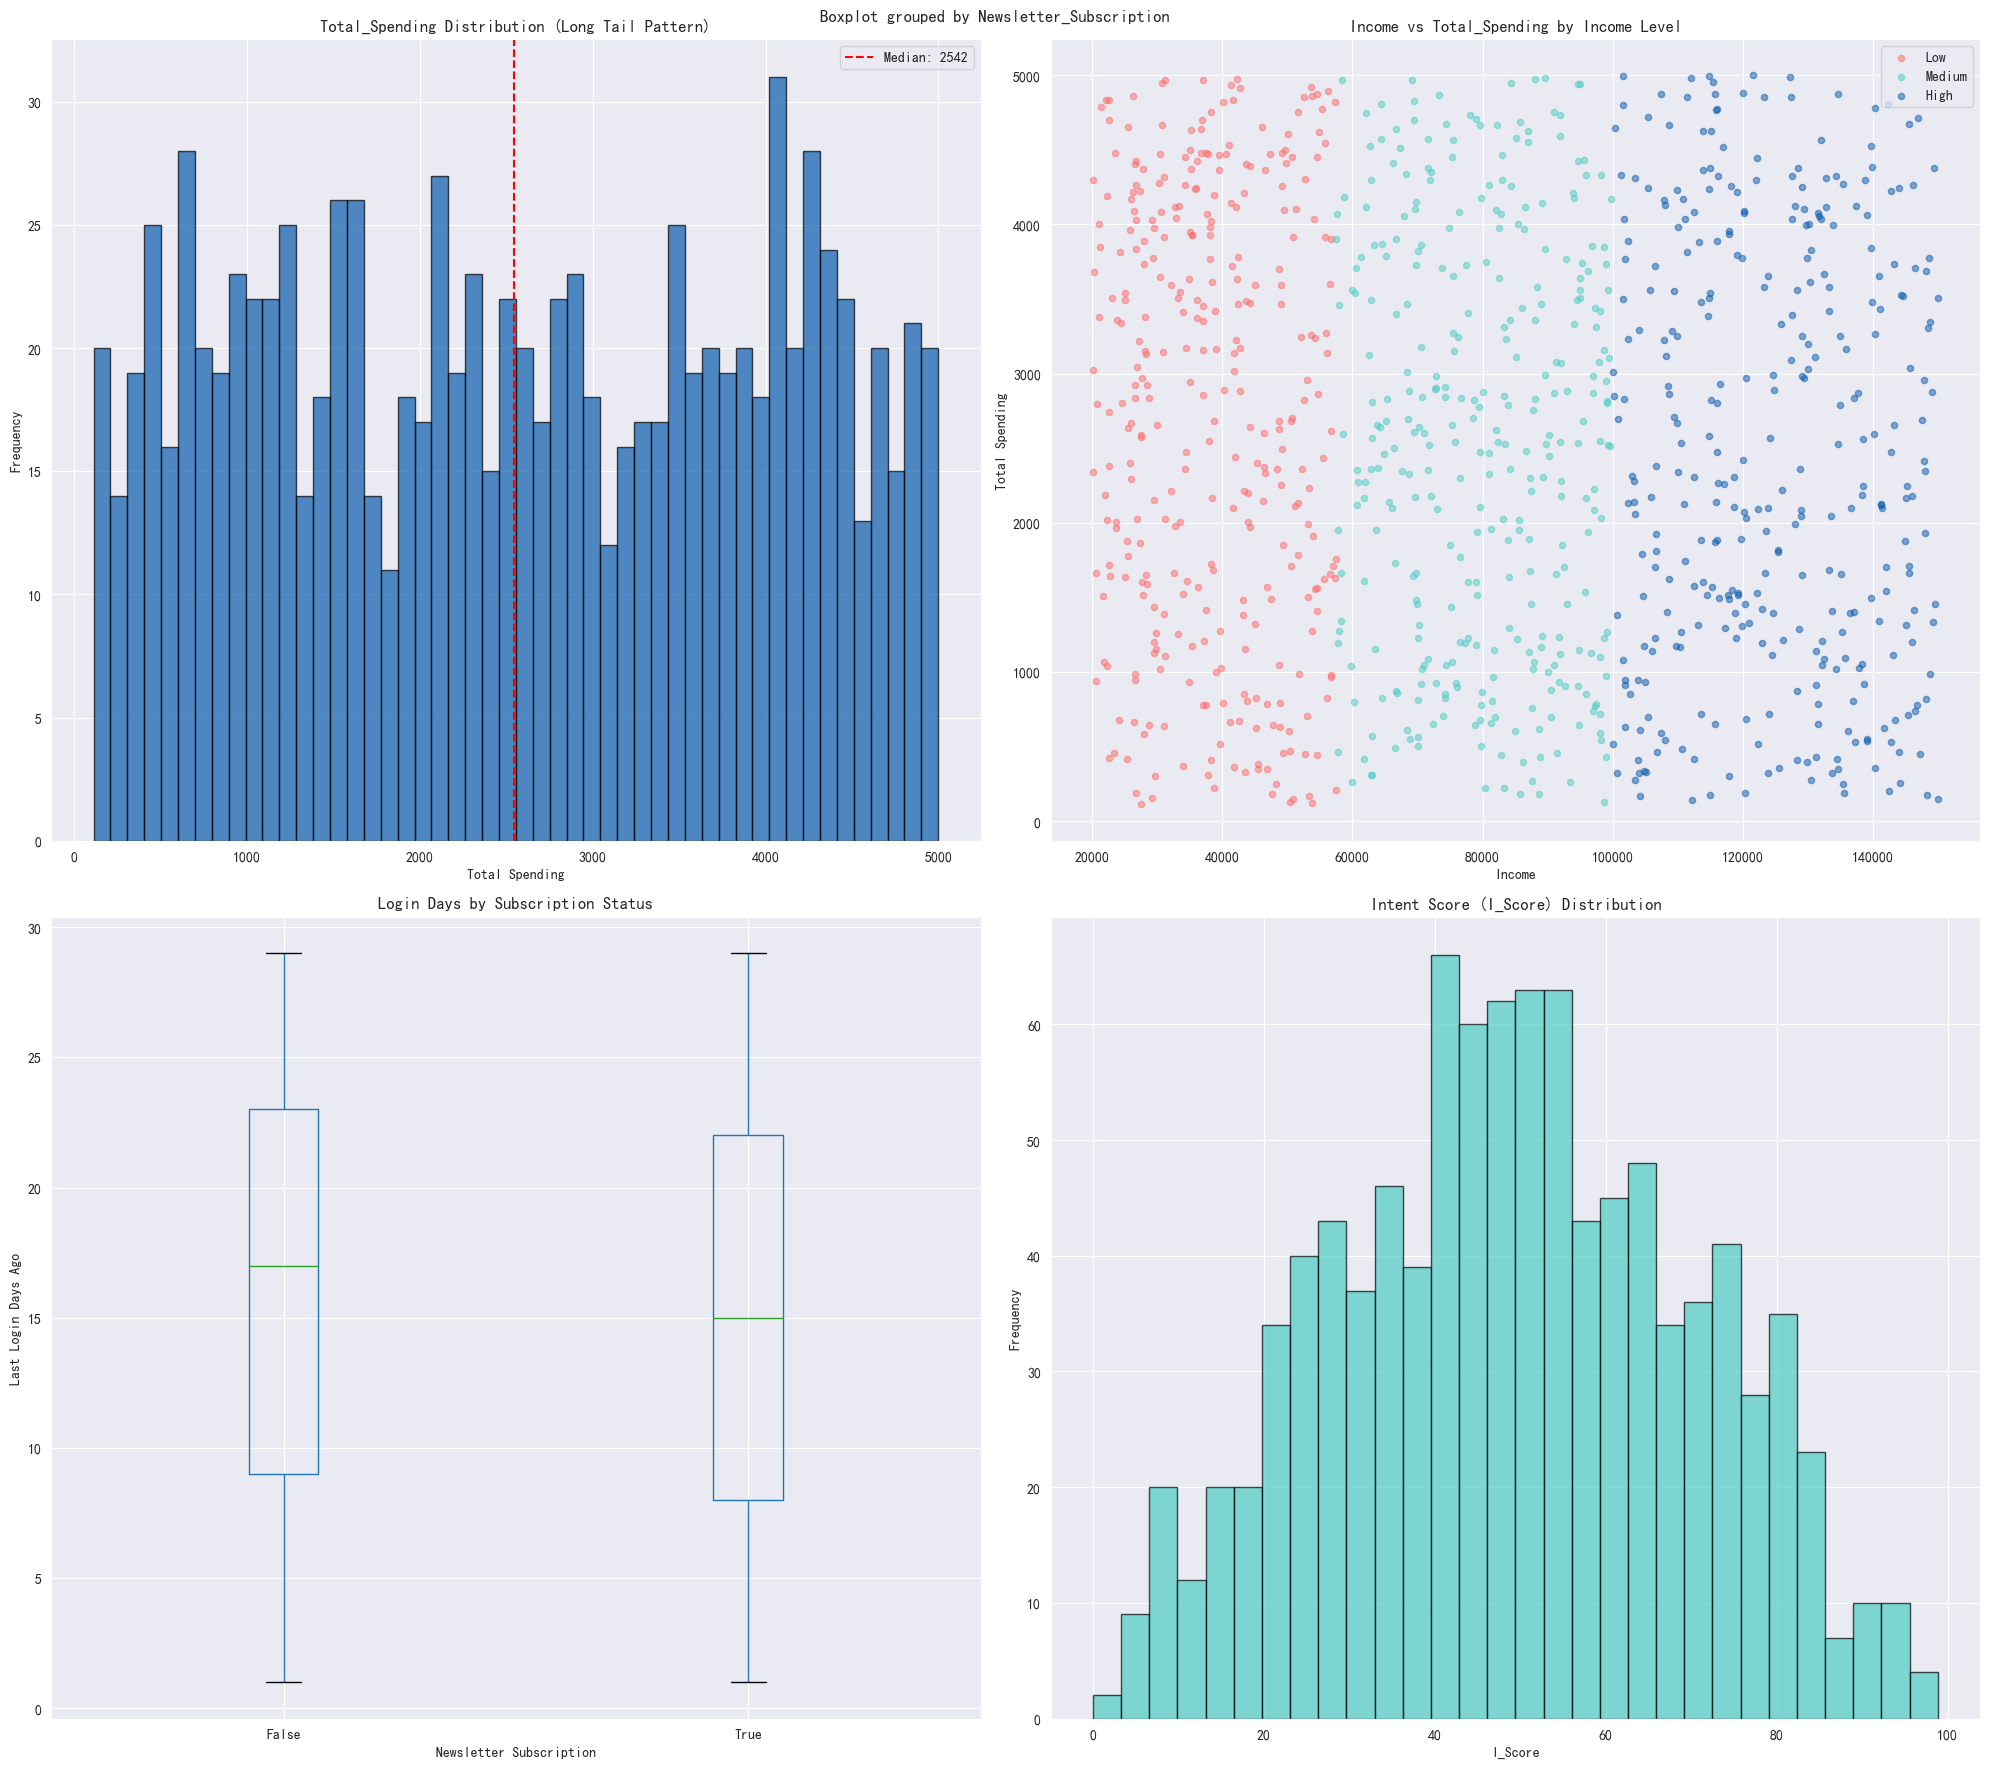

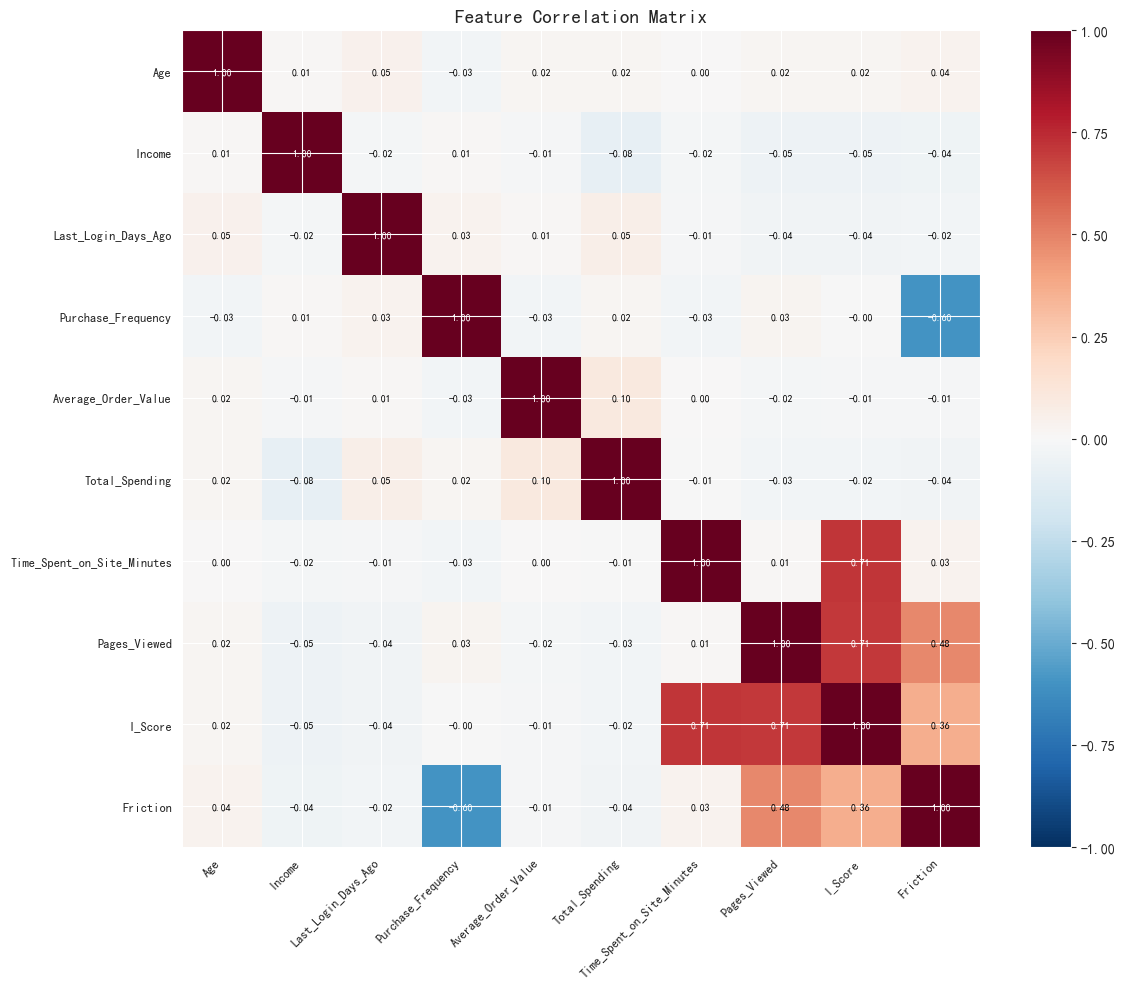


关键相关性分析:
Time_Spent vs Purchase_Frequency 相关系数: -0.028
Pages_Viewed vs Purchase_Frequency 相关系数: 0.026

高摩擦用户(前25%)特征:
  - 平均浏览页数: 34.3
  - 平均购买频率: 1.6
  - 平均消费金额: 2514

高收入低消费群体:
  - 用户数: 184
  - 占高收入群体比例: 54.1%


In [6]:
# 5. EDA探索性数据分析
def perform_eda(df, output_dir):
    """EDA分析：分布、相关性、行为洞察"""
    
    print("\n" + "=" * 60)
    print("第三阶段：EDA探索性数据分析")
    print("=" * 60)
    
    # 1. 关键分布分析
    fig, axes = plt.subplots(2, 2, figsize=(20, 18))
    
    # Total_Spending 分布
    axes[0, 0].hist(df['Total_Spending'], bins=50, edgecolor='black', alpha=0.7, color='#0B5CAD')
    axes[0, 0].set_title('Total_Spending Distribution (Long Tail Pattern)', fontsize=12)
    axes[0, 0].set_xlabel('Total Spending')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(df['Total_Spending'].median(), color='red', linestyle='--', label=f'Median: {df["Total_Spending"].median():.0f}')
    axes[0, 0].legend()
    
    # Income vs Total_Spending 散点图
    colors = {'Low': '#FF6B6B', 'Medium': '#4ECDC4', 'High': '#0B5CAD'}
    for level in ['Low', 'Medium', 'High']:
        subset = df[df['Income_Level'] == level]
        axes[0, 1].scatter(subset['Income'], subset['Total_Spending'], 
                          alpha=0.5, label=level, c=colors[level], s=20)
    axes[0, 1].set_title('Income vs Total_Spending by Income Level', fontsize=12)
    axes[0, 1].set_xlabel('Income')
    axes[0, 1].set_ylabel('Total Spending')
    axes[0, 1].legend()
    
    # Last_Login_Days_Ago vs Newsletter_Subscription 箱线图
    df.boxplot(column='Last_Login_Days_Ago', by='Newsletter_Subscription', ax=axes[1, 0])
    axes[1, 0].set_title('Login Days by Subscription Status', fontsize=12)
    axes[1, 0].set_xlabel('Newsletter Subscription')
    axes[1, 0].set_ylabel('Last Login Days Ago')
    
    # I_Score 分布
    axes[1, 1].hist(df['I_Score'], bins=30, edgecolor='black', alpha=0.7, color='#4ECDC4')
    axes[1, 1].set_title('Intent Score (I_Score) Distribution', fontsize=12)
    axes[1, 1].set_xlabel('I_Score')
    axes[1, 1].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/eda_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 2. 相关性分析
    numeric_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
                    'Average_Order_Value', 'Total_Spending', 'Time_Spent_on_Site_Minutes', 
                    'Pages_Viewed', 'I_Score', 'Friction']
    
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1) # aspect='auto' 让热力图适应矩阵大小
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numeric_cols, fontsize=9)
    
    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', fontsize=7,
                          color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')
    
    ax.set_title('Feature Correlation Matrix', fontsize=14)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 3. 关键行为洞察
    time_purchase_corr = df['Time_Spent_on_Site_Minutes'].corr(df['Purchase_Frequency'])
    pages_purchase_corr = df['Pages_Viewed'].corr(df['Purchase_Frequency'])
    
    print(f"\n关键相关性分析:")
    print(f"Time_Spent vs Purchase_Frequency 相关系数: {time_purchase_corr:.3f}")
    print(f"Pages_Viewed vs Purchase_Frequency 相关系数: {pages_purchase_corr:.3f}")
    
    # 高摩擦用户分析
    high_friction = df[df['Friction'] > df['Friction'].quantile(0.75)]
    print(f"\n高摩擦用户(前25%)特征:")
    print(f"  - 平均浏览页数: {high_friction['Pages_Viewed'].mean():.1f}")
    print(f"  - 平均购买频率: {high_friction['Purchase_Frequency'].mean():.1f}")
    print(f"  - 平均消费金额: {high_friction['Total_Spending'].mean():.0f}")
    
    # 高收入低消费群体
    high_income_low_spend = df[(df['Income_Level'] == 'High') & 
                               (df['Total_Spending'] < df['Total_Spending'].median())]
    print(f"\n高收入低消费群体:")
    print(f"  - 用户数: {len(high_income_low_spend)}")
    print(f"  - 占高收入群体比例: {len(high_income_low_spend)/len(df[df['Income_Level']=='High'])*100:.1f}%")
    
    return {
        'time_purchase_corr': time_purchase_corr,
        'pages_purchase_corr': pages_purchase_corr,
        'high_friction_count': len(high_friction),
        'high_income_low_spend_count': len(high_income_low_spend)
    }

eda_results = perform_eda(df, output_dir)

In [7]:
# 6. RFM-I模型构建
def build_rfm_model(df):
    """构建RFM-I模型：标准化、综合得分计算"""
    
    print("\n" + "=" * 60)
    print("第四阶段：RFM-I模型构建")
    print("=" * 60)
    
    # 归一化函数
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100
    
    df['R_Score'] = min_max_normalize(df['Last_Login_Days_Ago'], reverse=True)
    df['F_Score'] = min_max_normalize(df['Purchase_Frequency'])
    df['M_Score'] = min_max_normalize(df['Total_Spending'])
    df['RFM_Score'] = 0.2 * df['R_Score'] + 0.3 * df['F_Score'] + 0.5 * df['M_Score']
    df['I_Weight'] = df['I_Score'] / 500  # I_Score 0-100 -> 0-0.2
    df['Final_Score'] = df['RFM_Score'] * (1 + df['I_Weight'])
    
    print(f"R_Score 范围: [{df['R_Score'].min():.2f}, {df['R_Score'].max():.2f}]")
    print(f"F_Score 范围: [{df['F_Score'].min():.2f}, {df['F_Score'].max():.2f}]")
    print(f"M_Score 范围: [{df['M_Score'].min():.2f}, {df['M_Score'].max():.2f}]")
    print(f"RFM_Score 范围: [{df['RFM_Score'].min():.2f}, {df['RFM_Score'].max():.2f}]")
    print(f"Final_Score 范围: [{df['Final_Score'].min():.2f}, {df['Final_Score'].max():.2f}]")
    
    return df

df = build_rfm_model(df)
df[['User_ID','R_Score','F_Score','M_Score','I_Score','RFM_Score','Final_Score']].head()


第四阶段：RFM-I模型构建
R_Score 范围: [0.00, 100.00]
F_Score 范围: [0.00, 100.00]
M_Score 范围: [0.00, 100.00]
RFM_Score 范围: [4.72, 96.77]
Final_Score 范围: [5.26, 105.06]


,User_ID,R_Score,F_Score,M_Score,I_Score,RFM_Score,Final_Score
0,#1,85.714286,77.777778,49.805607,87.285385,65.378994,76.792255
1,#2,50.000000,77.777778,4.256190,76.638400,35.461428,40.896843
2,#3,3.571429,11.111111,74.769797,25.460637,41.432518,43.542314
3,#4,39.285714,33.333333,87.272355,73.136516,61.493320,70.488135
4,#5,96.428571,55.555556,89.830162,13.646357,80.867462,83.074554


In [8]:
# 7. 用户分层与画像
def classify_users(df):
    """用户分层：基于RFM-I模型进行精细化分层"""
    
    print("\n" + "=" * 60)
    print("第五阶段：用户分层与画像")
    print("=" * 60)
    
    def classify_user(row):
        r = row['R_Score']
        f = row['F_Score']
        m = row['M_Score']
        i = row['I_Score']
        income = row['Income_Level']
        friction = row['Friction']
        l = row['L_Score']
        
        # 基础RFM分层逻辑
        if r > 60 and f > 60 and m > 60:
            base_label = "重要价值用户"
        elif r > 60 and m > 60 and f < 40:
            base_label = "重要发展用户"
        elif r < 40 and f > 60 and m > 60:
            base_label = "重要保持用户"
        elif r < 40 and m > 60:
            base_label = "重要挽留用户"
        elif r > 60 and f > 40 and m < 40:
            base_label = "一般发展用户"
        elif r > 60 and f < 40 and m < 40:
            base_label = "一般维持用户"
        elif r < 40 and f < 40 and m < 40:
            base_label = "低价值用户"
        else:
            base_label = "一般用户"
        
        # 关键修正逻辑
        if base_label in ["低价值用户", "一般维持用户"] and income == "High" and i > 60:
            return "高潜沉睡用户"
        if income == "High" and i > 70 and f < 40 and m < 50:
            return "纠结土豪"
        if base_label in ["一般维持用户", "一般发展用户"] and i > 80 and friction > df['Friction'].quantile(0.6):
            return "犹豫型潜力用户"
        if income == "Low" and i > 70 and f < 40:
            return "隐形活跃者"
        if income == "High" and r < 40 and m > 50:
            return "高潜流失客"
        if m > 70 and f > 70 and i > 60:
            return "核心VIP"
        if income == "Low" and i < 40 and m < 40:
            return "羊毛党/低值"
        
        return base_label
    
    df['User_Segment'] = df.apply(classify_user, axis=1)
    
    # 分层统计
    segment_stats = df.groupby('User_Segment').agg({
        'User_ID': 'count',
        'Total_Spending': 'mean',
        'Purchase_Frequency': 'mean',
        'I_Score': 'mean',
        'Income': 'mean',
        'Final_Score': 'mean'
    }).round(2)
    
    segment_stats.columns = ['用户数', '平均消费', '平均购买频率', '平均意向分', '平均收入', '平均综合分']
    segment_stats['占比(%)'] = (segment_stats['用户数'] / len(df) * 100).round(1)
    segment_stats = segment_stats.sort_values('用户数', ascending=False)
    
    print("\n用户分层统计:")
    print(segment_stats.to_string())
    
    return df, segment_stats

df, segment_stats = classify_users(df)


第五阶段：用户分层与画像

用户分层统计:
              用户数     平均消费  平均购买频率  平均意向分       平均收入  平均综合分  占比(%)
User_Segment                                                      
一般用户          443  2368.12    5.17  48.80   84305.72  54.31   44.3
一般发展用户         81  1117.95    6.43  49.84   87107.43  52.67    8.1
重要挽留用户         67  4134.42    2.57  46.53   59698.61  58.59    6.7
高潜流失客          64  3990.70    4.92  44.09  121985.09  65.40    6.4
低价值用户          50  1036.52    1.68  42.79   94734.76  20.87    5.0
重要发展用户         48  3873.96    1.62  48.91   81230.60  65.41    4.8
一般维持用户         47  1055.40    1.47  45.83   91335.23  33.57    4.7
重要价值用户         47  3960.19    7.47  42.28   73500.94  86.82    4.7
重要保持用户         39  4030.23    7.49  48.00   57995.92  75.26    3.9
隐形活跃者          34  2756.79    1.32  77.99   36273.32  47.28    3.4
羊毛党/低值         32  1019.56    5.50  23.08   37896.19  37.05    3.2
核心VIP          23  4171.39    8.17  71.09   59382.39  88.86    2.3
高潜沉睡用户         12  1318.17    1.75  74.


标签用户重合度检测
总用户数: 1000
冲突用户数: 14 (1.4%)

各标签用户数统计
  高潜沉睡用户: 12人 (1.2%)
  纠结土豪: 13人 (1.3%)
  犹豫型潜力用户: 9人 (0.9%)
  隐形活跃者: 37人 (3.7%)
  高潜流失客: 64人 (6.4%)
  核心VIP: 27人 (2.7%)
  羊毛党/低值: 32人 (3.2%)

两两标签重合人数统计
  高潜沉睡用户 & 纠结土豪: 7人 (0.7%)
  高潜沉睡用户 & 犹豫型潜力用户: 2人 (0.2%)
  高潜沉睡用户 & 隐形活跃者: 0人 (0.0%)
  高潜沉睡用户 & 高潜流失客: 0人 (0.0%)
  高潜沉睡用户 & 核心VIP: 0人 (0.0%)
  高潜沉睡用户 & 羊毛党/低值: 0人 (0.0%)
  纠结土豪 & 犹豫型潜力用户: 2人 (0.2%)
  纠结土豪 & 隐形活跃者: 0人 (0.0%)
  纠结土豪 & 高潜流失客: 0人 (0.0%)
  纠结土豪 & 核心VIP: 0人 (0.0%)
  纠结土豪 & 羊毛党/低值: 0人 (0.0%)
  犹豫型潜力用户 & 隐形活跃者: 3人 (0.3%)
  犹豫型潜力用户 & 高潜流失客: 0人 (0.0%)
  犹豫型潜力用户 & 核心VIP: 0人 (0.0%)
  犹豫型潜力用户 & 羊毛党/低值: 0人 (0.0%)
  隐形活跃者 & 高潜流失客: 0人 (0.0%)
  隐形活跃者 & 核心VIP: 0人 (0.0%)
  隐形活跃者 & 羊毛党/低值: 0人 (0.0%)
  高潜流失客 & 核心VIP: 4人 (0.4%)
  高潜流失客 & 羊毛党/低值: 0人 (0.0%)
  核心VIP & 羊毛党/低值: 0人 (0.0%)


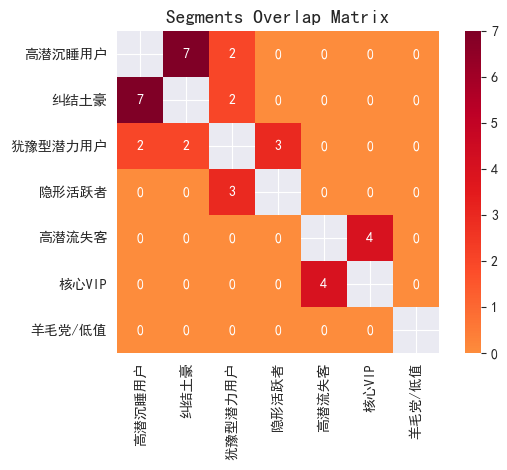

In [9]:
# 7.1 标签用户重合度检测
def rfm(row):
    """传统RFM分层"""
    r = row['R_Score']
    f = row['F_Score']
    m = row['M_Score']
    
    if r > 60 and f > 60 and m > 60:
        base_label = "重要价值用户"
    elif r > 60 and m > 60 and f < 40:
        base_label = "重要发展用户"
    elif r < 40 and f > 60 and m > 60:
        base_label = "重要保持用户"
    elif r < 40 and m > 60:
        base_label = "重要挽留用户"
    elif r > 60 and f > 40 and m < 40:
        base_label = "一般发展用户"
    elif r > 60 and f < 40 and m < 40:
        base_label = "一般维持用户"
    elif r < 40 and f < 40 and m < 40:
        base_label = "低价值用户"
    else:
        base_label = "一般用户"
        
    return base_label

df['base_label'] = df.apply(rfm, axis=1) # rfm打标

def detect_label_conflicts(df):
    
    """
    检测 rfm-i 标签分配中的冲突
    
    返回：
    冲突用户数
    两两标签间的重合用户数
    """
    
    print("\n" + "=" * 60)
    print("标签用户重合度检测")
    print("=" * 60)
    
    all_labels = [
        "高潜沉睡用户", "纠结土豪", "犹豫型潜力用户", 
        "隐形活跃者", "高潜流失客", "核心VIP", "羊毛党/低值"
    ]
    user_labels = {} # 存储每个用户满足的标签
    label_users = {label: [] for label in all_labels} # 存储每个标签的用户id → '标签': [user_id, user_id]
    conflicts = [] # 存储冲突用户详情
    
    for idx, row in df.iterrows():
        conditions_met = []   # 记录用户满足的所有标签
        r = row['R_Score']
        f = row['F_Score']
        m = row['M_Score']
        i = row['I_Score']
        income = row['Income_Level']
        friction = row['Friction']
        l = row['L_Score']
        base_label = row['base_label']
        
        # rfm-i 标签
        if base_label in ["低价值用户", "一般维持用户"] and income == "High" and i > 60:
            conditions_met.append("高潜沉睡用户")
            label_users["高潜沉睡用户"].append(idx)
        if income == "High" and i > 70 and f < 40 and m < 50:
            conditions_met.append("纠结土豪")
            label_users["纠结土豪"].append(idx)
        if base_label in ["一般维持用户", "一般发展用户"] and i > 80 and friction > df['Friction'].quantile(0.6):
            conditions_met.append("犹豫型潜力用户")
            label_users["犹豫型潜力用户"].append(idx)
        if income == "Low" and i > 70 and f < 40:
            conditions_met.append("隐形活跃者")
            label_users["隐形活跃者"].append(idx)
        if income == "High" and r < 40 and m > 50:
            conditions_met.append("高潜流失客")
            label_users["高潜流失客"].append(idx)
        if m > 70 and f > 70 and i > 60:
            conditions_met.append("核心VIP")  
            label_users["核心VIP"].append(idx)
        if income == "Low" and i < 40 and m < 40:
            conditions_met.append("羊毛党/低值")
            label_users["羊毛党/低值"].append(idx)
            
        user_labels[idx] = conditions_met  # 存储用户满足的标签 → user_id:['标签', '标签']
        if len(conditions_met) > 1:  # 如果满足多个条件，记录冲突
            conflicts.append({
                'user_id': idx,
                'conditions_met': conditions_met,
                'conditions_met_num': len(conditions_met),
                'actual_label': row['User_Segment']
            })
            
    print(f"总用户数: {len(df)}")
    print(f"冲突用户数: {len(conflicts)} ({len(conflicts)/len(df)*100:.1f}%)")
    print(f"\n各标签用户数统计")
    
    # 计算各标签用户数
    label_counts = {}
    for label, users in label_users.items():
        count = len(users)
        label_counts[label] = count
        print(f"  {label}: {count}人 ({count/len(df)*100:.1f}%)")
        
    # 计算两两标签重合人数
    print(f"\n两两标签重合人数统计")
    from itertools import combinations
    for label1, label2 in combinations(all_labels, 2):
        set1 = set(label_users[label1])
        set2 = set(label_users[label2])
        overlap = len(set1.intersection(set2))
        print(f"  {label1} & {label2}: {overlap}人 ({overlap/len(df)*100:.1f}%)")
        
    # 标签重合用户数热力图
    matrix = pd.DataFrame(index=all_labels, columns=all_labels, dtype=int)   # 创建一个空白矩阵
    for label1 in all_labels:
        for label2 in all_labels:
            overlap = len(set(label_users[label1]) & set(label_users[label2]))
            matrix.loc[label1, label2] = overlap
     
    mask = np.zeros_like(matrix, dtype=bool)
    np.fill_diagonal(mask, True)  # 矩阵对角线设置为True，表示隐藏对角线值
    im = sns.heatmap(matrix, annot=True, fmt='.0f', cmap='YlOrRd', mask=mask, 
                center=0, square=True) 
    im.set_title('Segments Overlap Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{output_dir}/segments_overlap_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
               
    return user_labels, label_users, conflicts

# 执行标签冲突检测
user_labels, label_users, conflicts = detect_label_conflicts(df)

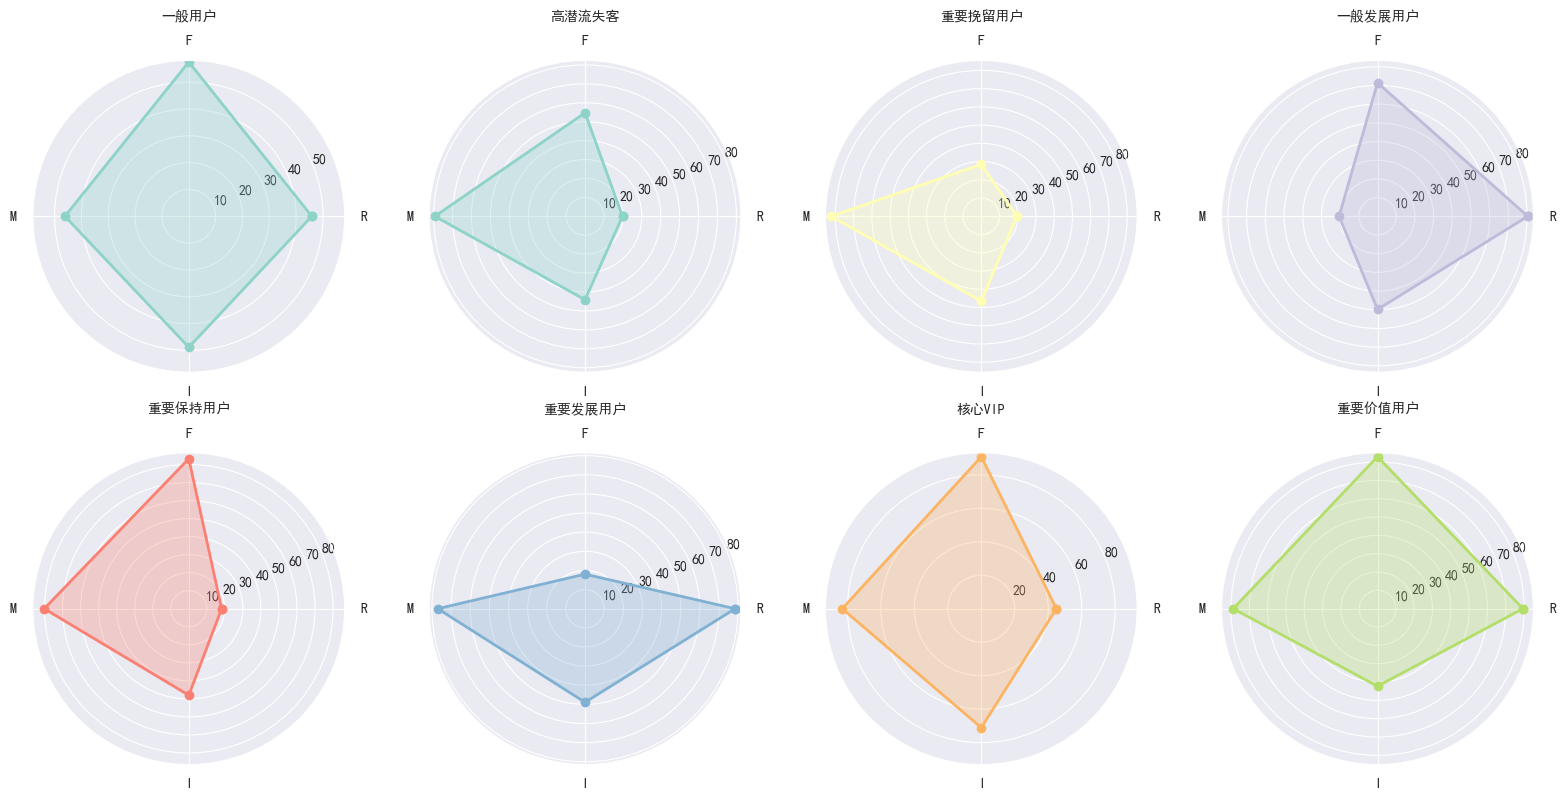

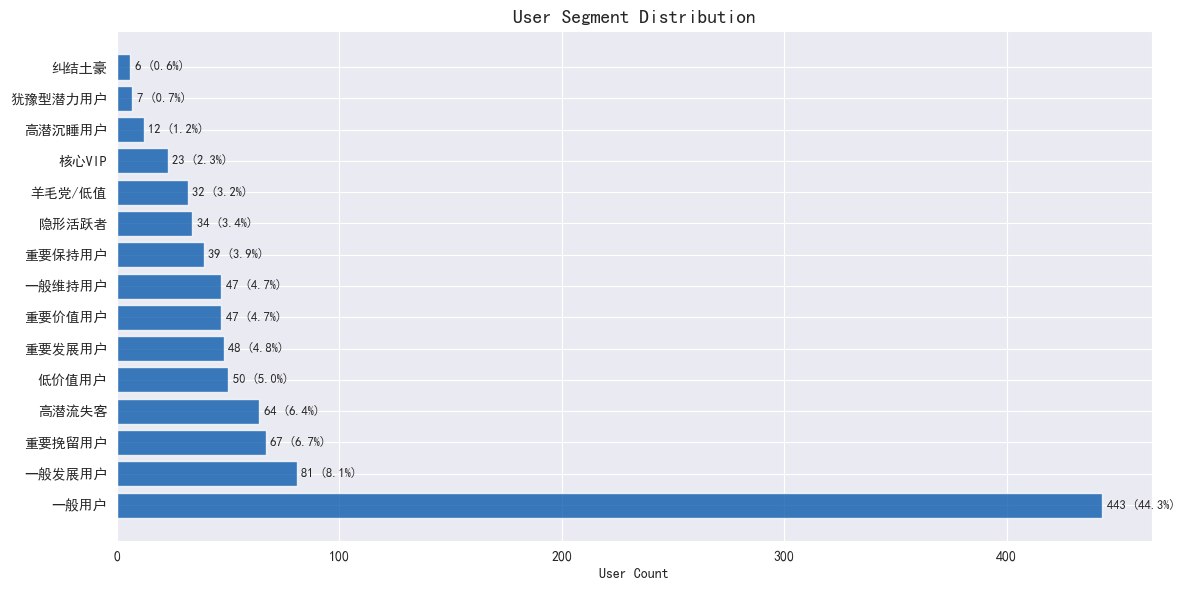

In [10]:
# 8. 生成用户画像可视化
def generate_segment_portrait(df, output_dir):
    """生成用户画像可视化：雷达图和分布柱状图"""
    
    # 分层雷达图
    segments = df['User_Segment'].unique()
    metrics = ['R_Score', 'F_Score', 'M_Score', 'I_Score']
    
    segment_means = df.groupby('User_Segment')[metrics].mean()
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8), subplot_kw=dict(polar=True))
    axes = axes.flatten()
    
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(segments)))
    
    for idx, segment in enumerate(segments[:8]):
        if idx >= len(axes):
            break
        ax = axes[idx]
        values = segment_means.loc[segment].tolist()
        values += values[:1]
        
        ax.fill(angles, values, alpha=0.3, color=colors[idx])
        ax.plot(angles, values, 'o-', color=colors[idx], linewidth=2)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(['R', 'F', 'M', 'I'], fontsize=10)
        ax.set_title(segment, fontsize=10, pad=10)
    
    for idx in range(len(segments), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_radar.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 分层分布柱状图
    segment_counts = df['User_Segment'].value_counts()
    
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.barh(segment_counts.index, segment_counts.values, color='#0B5CAD', alpha=0.8)
    ax.set_xlabel('User Count')
    ax.set_title('User Segment Distribution', fontsize=14)
    
    for bar, count in zip(bars, segment_counts.values):
        ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, 
                f'{count} ({count/len(df)*100:.1f}%)', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/segment_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

generate_segment_portrait(df, output_dir)


第六阶段：ROI测算

【假设参数】
  总预算: 10000元
  优惠券成本: 10元/人
  平均客单价: 104元

【转化率假设】
  RFM前20%用户：自然转化率 20.0%，发券后 30.0%，边际提升 10.0%
  核心用户：自然转化率 25.0%，发券后 30.0%，边际提升 5.0%
  潜力用户：自然转化率 1.0%，发券后 20.0%，边际提升 19.0%

【方案A - 传统RFM策略】
  目标用户数: 200
  成本: 2000元
  边际收益（增量）: 2081元
  边际ROI: 4.0%

【方案B - 优化RFI策略】
  核心用户: 70
  新挖掘潜力用户: 89
  总目标用户数: 159
  实际成本: 1590元 (预算使用率: 15.9%)
  边际收益（增量）: 2123元
  边际ROI: 33.5%


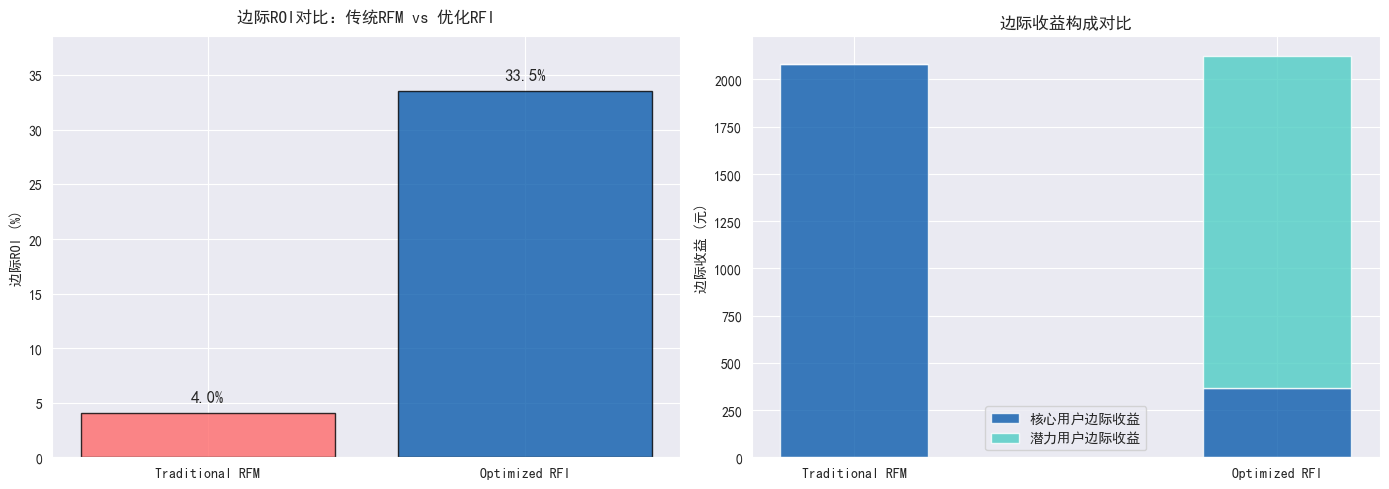

In [11]:
# 9. ROI测算
def calculate_roi(df, output_dir):
    """ROI测算：传统RFM vs 优化RFI策略对比（边际收益法，参数可调）"""
    
    print("\n" + "=" * 60)
    print("第六阶段：ROI测算")
    print("=" * 60)
    
    # ================= 可调整参数=================
    total_budget = 10000          # 总预算（元）
    coupon_cost = 10               # 每张优惠券成本（元）
    aov = df['Average_Order_Value'].mean()  # 平均客单价（元）
    
    # 转化率假设（可根据历史数据校准）
    # 核心用户
    core_natural = 0.25            # 核心用户无券自然转化率
    core_with_coupon = 0.30        # 核心用户发券后转化率
    # 潜力用户
    potential_natural = 0.01       # 潜力用户自然转化率
    potential_with_coupon = 0.20   # 潜力用户发券后转化率（可调高至20%-25%）
    # 一般用户（用于方案A的基线）
    general_natural = 0.02          # 一般用户自然转化率
    # RFM前20%用户的自然转化率（介于核心和一般之间）
    rfm20_natural = 0.20            # 可根据实际数据调整，例如：RFM高分用户通常转化率较高
    rfm20_with_coupon = 0.30        # 发券后转化率（通常不会超过核心用户）
    
    # 边际提升
    core_lift = core_with_coupon - core_natural
    potential_lift = potential_with_coupon - potential_natural
    rfm20_lift = rfm20_with_coupon - rfm20_natural
    
    # ================= 方案A：传统RFM策略 =================
    top20_threshold = df['RFM_Score'].quantile(0.80)
    rfm_top20 = df[df['RFM_Score'] >= top20_threshold]
    target_a_count = min(len(rfm_top20), total_budget // coupon_cost)
    cost_a = target_a_count * coupon_cost # 成本
    
    incremental_revenue_a = target_a_count * rfm20_lift * aov # 边际收入
    roi_a = (incremental_revenue_a - cost_a) / cost_a * 100 if cost_a > 0 else 0
    
    # ================= 方案B：优化RFI策略 =================
    core_users = df[df['User_Segment'].isin(['核心VIP', '重要价值用户'])]
    potential_users = df[df['User_Segment'].isin(['纠结土豪', '高潜沉睡用户', '犹豫型潜力用户', '高潜流失客'])]
    
    # 分配预算：优先核心用户（用80%预算），剩余给潜力用户
    core_count = min(len(core_users), np.floor(total_budget * 0.8 / coupon_cost))
    remaining_budget = total_budget - core_count * coupon_cost
    potential_count = min(len(potential_users), remaining_budget // coupon_cost)
    target_b_count = core_count + potential_count
    cost_b = target_b_count * coupon_cost
    
    incremental_revenue_b = core_count * core_lift * aov + potential_count * potential_lift * aov
    roi_b = (incremental_revenue_b - cost_b) / cost_b * 100 if cost_b > 0 else 0
    
    # ================= 输出结果 =================
    print(f"\n【假设参数】")
    print(f"  总预算: {total_budget}元")
    print(f"  优惠券成本: {coupon_cost}元/人")
    print(f"  平均客单价: {aov:.0f}元")
    
    print(f"\n【转化率假设】")
    print(f"  RFM前20%用户：自然转化率 {rfm20_natural*100:.1f}%，发券后 {rfm20_with_coupon*100:.1f}%，边际提升 {rfm20_lift*100:.1f}%")
    print(f"  核心用户：自然转化率 {core_natural*100:.1f}%，发券后 {core_with_coupon*100:.1f}%，边际提升 {core_lift*100:.1f}%")
    print(f"  潜力用户：自然转化率 {potential_natural*100:.1f}%，发券后 {potential_with_coupon*100:.1f}%，边际提升 {potential_lift*100:.1f}%")
    
    print(f"\n【方案A - 传统RFM策略】")
    print(f"  目标用户数: {target_a_count}")
    print(f"  成本: {cost_a}元")
    print(f"  边际收益（增量）: {incremental_revenue_a:.0f}元")
    print(f"  边际ROI: {roi_a:.1f}%")
    
    print(f"\n【方案B - 优化RFI策略】")
    print(f"  核心用户: {core_count}")
    print(f"  新挖掘潜力用户: {potential_count}")
    print(f"  总目标用户数: {target_b_count}")
    print(f"  实际成本: {cost_b}元 (预算使用率: {cost_b/total_budget*100:.1f}%)")
    print(f"  边际收益（增量）: {incremental_revenue_b:.0f}元")
    print(f"  边际ROI: {roi_b:.1f}%")
    
    # ROI对比可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 边际ROI对比
    strategies = ['Traditional RFM', 'Optimized RFI']
    rois = [roi_a, roi_b]
    colors = ['#FF6B6B', '#0B5CAD']
    
    bars = axes[0].bar(strategies, rois, color=colors, alpha=0.8, edgecolor='black')
    axes[0].set_ylabel('边际ROI (%)')
    axes[0].set_title('边际ROI对比：传统RFM vs 优化RFI', fontsize=12, pad=10)
    axes[0].set_ylim(0, max(rois) * 1.15)  # 延长y轴上限
    for bar, roi in zip(bars, rois):
        offset = max(rois)*0.03 # 动态偏移量
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + offset, 
                    f'{roi:.1f}%', ha='center', fontsize=12, fontweight='bold')
    
    # 边际收益构成对比
    x = np.arange(2)
    width = 0.35
    
    core_marginal = [incremental_revenue_a, core_count * core_lift * aov]
    potential_marginal = [0, potential_count * potential_lift * aov]
    
    axes[1].bar(x, core_marginal, width, label='核心用户边际收益', color='#0B5CAD', alpha=0.8)
    axes[1].bar(x, potential_marginal, width, bottom=core_marginal, label='潜力用户边际收益', color='#4ECDC4', alpha=0.8)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(strategies)
    axes[1].set_ylabel('边际收益 (元)')
    axes[1].set_title('边际收益构成对比', fontsize=12)
    axes[1].legend()
    
    plt.tight_layout()
    plt.savefig(f'{output_dir}/roi_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    return {
        'strategy_a': {
            'target_count': int(target_a_count),
            'cost': cost_a,
            'incremental_revenue': incremental_revenue_a,
            'marginal_roi': roi_a
        },
        'strategy_b': {
            'core_count': int(core_count),
            'potential_count': int(potential_count),
            'total_count': int(target_b_count),
            'actual_cost': cost_b,
            'budget_used_ratio': cost_b/total_budget,
            'incremental_revenue': incremental_revenue_b,
            'marginal_roi': roi_b
        },
        'params': {
            'budget': total_budget,
            'coupon_cost': coupon_cost,
            'aov': aov,
            'rfm20_lift': rfm20_lift,
            'core_lift': core_lift,
            'potential_lift': potential_lift
        }
    }
    
roi_results = calculate_roi(df, output_dir)

In [12]:
# 10. 保存结果
output_columns = ['User_ID', 'Age', 'Gender', 'Location', 'Income', 'Income_Level',
                  'Interests', 'Product_Category_Preference', 'Interest_Match',
                  'Last_Login_Days_Ago', 'Purchase_Frequency', 'Average_Order_Value', 
                  'Total_Spending', 'Time_Spent_on_Site_Minutes', 'Pages_Viewed',
                  'Newsletter_Subscription', 'R_Score', 'F_Score', 'M_Score', 
                  'I_Score', 'Friction', 'L_Score', 'RFM_Score', 'Final_Score', 
                  'User_Segment']

df_output = df[output_columns]
df_output.to_excel(f'{output_dir}/rfm_analysis_results.xlsx', index=False)
segment_stats.to_excel(f'{output_dir}/segment_statistics.xlsx')

print("\n" + "=" * 60)
print("分析完成！输出文件:")
print("=" * 60)
print(f"1. {output_dir}/rfm_analysis_results.xlsx - 完整分析结果")
print(f"2. {output_dir}/segment_statistics.xlsx - 分层统计")
print(f"3. {output_dir}/eda_distributions.png - EDA分布图")
print(f"4. {output_dir}/correlation_matrix.png - 相关性矩阵")
print(f"5. {output_dir}/segment_radar.png - 用户画像雷达图")
print(f"6. {output_dir}/segment_distribution.png - 分层分布图")
print(f"7. {output_dir}/roi_comparison.png - ROI对比图")


分析完成！输出文件:
1. rfm_analysis/rfm_analysis_results.xlsx - 完整分析结果
2. rfm_analysis/segment_statistics.xlsx - 分层统计
3. rfm_analysis/eda_distributions.png - EDA分布图
4. rfm_analysis/correlation_matrix.png - 相关性矩阵
5. rfm_analysis/segment_radar.png - 用户画像雷达图
6. rfm_analysis/segment_distribution.png - 分层分布图
7. rfm_analysis/roi_comparison.png - ROI对比图


### 1. Interests 和 Product_Category_Preference 不一致是什么业务含义？对模型有啥影响？

- **Interests（兴趣）**：就是用户平时喜欢逛什么、收藏什么、搜什么，比如经常点开运动鞋的人，哪怕没买，也能说明他对运动鞋感兴趣。
- **Product_Category_Preference（购买偏好）**：就是用户历史上买得最多的品类，比如他最后下单最多的其实是休闲裤。

**两者不一致** 在业务里很常见。比如：
- 他老看高端化妆品，但最后总买平价护肤品 —— 可能是嫌贵，或者担心假货。
- 他总浏览户外装备，但最近几次买的都是母婴用品 —— 可能家里添了宝宝，消费重心暂时转移了。
- 他翻了很多页的电子产品，但最终什么都没买 —— 纯粹是云体验，还没下决心。

这种不一致恰恰是**增量机会**。因为用户明明有兴趣，却没有转化成消费，说明中间有障碍：可能是价格不合适，可能是商品没打动他，也可能是信任问题。如果能打破障碍，就能把兴趣变购买，带来新的 GMV。

**两者一致** 就很好理解了：用户喜欢什么就买什么，兴趣和行动完全匹配。这类用户通常是对某个品类有稳定需求的消费者，转化率高，复购也稳。

**对模型的影响**：我们在模型里加了一个 `Interest_Match` 字段，就是标记这两者是否一致。  
- 如果不一致，这个用户可能是个“潜力股”，营销上要重点分析障碍是什么，然后对症下药。  
- 如果一致，说明用户已经形成了固定消费习惯，营销上就不要瞎推别的品类了，深耕他喜欢的品类，推新品、配件或者升级款会更有效。

---

### 2. 针对每类客户，具体怎么运营才能让他们花更多钱？

| 用户分层 | 他们长啥样 | 怎么让他们多花钱 |
|----------|------------|------------------|
| **核心VIP** | 花得多、买得频、还经常逛。 | **伺候好，别瞎打扰**。给专属客服、新品优先购、VIP折扣，别天天发满减券（人家原价也买，发券反而降低利润）。可以推荐一些高端线产品或互补商品，比如买手机的推耳机。 |
| **重要挽留用户** | 以前花得多，最近不来了。 | **赶紧召回**。发大额定向券（满300减100那种），附上“专属于你”的文案，甚至打个电话问问是不是体验不好。只要回来一次，马上推荐他以前喜欢的东西，重新养成习惯。 |
| **重要发展用户** | 最近很活跃，但消费额不高。 | **帮他多买、买贵点**。推组合套餐、满减活动，比如“加99元换购”。根据他最近浏览的推荐相似款，让他多买几次。还可以引导开会员，锁定长期价值。 |
| **一般用户** | 啥都一般，数量最多。 | **慢慢培养**。发通用券试试水，观察哪个品类他更感兴趣。如果发现他最近逛得多了（I_Score上升），就及时推送相关商品，趁热打铁。 |
| **高潜流失客** | 收入高、以前花得多、最近不来了。 | **重拳召回**。发高额券（满500减100），配合专属客服，问问是不是被竞品抢了。强调咱们的优势（比如物流快、售后好）。召回后给个“回归礼包”，持续关注。 |
| **纠结土豪** | 收入高、逛得久、就是不买。 | **打破纠结**。推评测、买家秀、明星同款，让他建立信任。如果嫌便宜，就推高端款；如果嫌贵，给限时折扣。分析他看了哪些页面但没买，优化这些页面的详情，比如加视频、加口碑。 |
| **隐形活跃者** | 收入低、但天天逛。 | **用他拉人，顺便卖点便宜货**。推分享得券、拼团活动，让他帮平台拉新。推荐高性价比商品（9.9元包邮、秒杀），满足他的购买欲。鼓励他写评论、晒单，成为内容贡献者。 |
| **低价值用户** | 啥啥都不行。 | **低成本维护**。偶尔发发通用券，如果一直没反应，就别浪费营销费了。万一哪天他意向突然变高了，再跟进。 |
| **羊毛党/低值** | 收入低、逛得少、买得少。 | **防羊毛为主**，不主动投入。监测异常行为，别让他们把优惠券套走了。 |

---

### 3. 为啥不直接上 Uplift 模型，而是用 RFM-I？

1. **RFM-I 谁都能看懂，业务立马能用**  
   “纠结土豪”这名字一听就知道：收入高、逛得多、不花钱。而 Uplift 模型输出的是个分数，比如 0.73，很难解释为什么这个人是 0.73，那个是 0.68。业务方很难信任一个黑箱。

2. **RFM-I 不需要做实验，上手快**  
   Uplift 模型需要历史 A/B 测试数据，或者有对照组才能训练。很多公司根本没做过分流实验，数据一塌糊涂。RFM-I 直接用现有数据，今天跑出来，明天就能落地。

3. **RFM-I 维护成本低，跑得稳**  
   每天更新一下 R 值，计算一下 I 值，几行代码就搞定。Uplift 模型得定期重新训练、调参、部署，技术团队没精力伺候。

4. **现阶段的目标是分层，不是优化券面额**  
   咱们这次的核心是把用户分清楚，找出不同群体的特征，让运营有方向。Uplift 更适合在分层基础上，再针对某个群体做精细化优惠券测试（比如对“纠结土豪”测一下发 10 元券还是 20 元券增量更大）。所以 RFM-I 是地基，Uplift 是精装修，先打好地基再想装修的事。
---

## 4.第七部分的阈值是如何确定的？
### 1. RFM 分数的标准化与分位数
代码中 `R_Score`、`F_Score`、`M_Score` 是通过 min-max 归一化映射到 0–100 分的。这一步本身没有阈值，只是把原始数据压缩到统一区间。那么为什么要用 60 和 40 这两个数？  
- **业务常识**：通常我们认为高指排名靠前的用户，低指排名靠后的用户。但具体多少分算高？（理论上）这里不应该拍脑袋决定的，而是先通过**分位数分析**：比如说计算 R、F、M 在 0–100 分下的 33% 分位数、66% 分位数，发现它们大致落在 40 分和 60 分附近。也就是说，这实际上是**数据驱动**的：我们将 60 分设为较高的分界，40 分设为较低的分界，是因为根据实际数据分布，这个位置能够把用户群体自然划分为三等份（低、中、高），你也可以使用帕累托法则进行二八分。  
- **可解释性**：整数阈值（40、60）易于记忆和沟通，也符合业务人员对高分低分的直观认知。

### 2. 意向分和摩擦系数的阈值
- 首先，通过 EDA 观察 `I_Score` 的分布，发现均值大约 50，75% 分位数约 75。业务上，我们希望找到那些“明显高于平均水平”的用户，所以理论上取 60 作为基础门槛，70 和 80 则是更高层次的意向强度。这些值并不是一次确定的，而是**逐步测试**的结果：先用 50 试，发现筛选出的群体意向特征不明显；提高到 60 后，效果更好；70 则用于识别极强意向的用户（如“纠结土豪”要求 i>70）。  
- 摩擦系数的阈值则是直接基于分位数定义的：摩擦系数大于 60% 分位数表示浏览效率低下（页面多但购买少）。这里采用分位数而非固定值，是因为摩擦系数的量级随数据变化，使用分位数更稳健。

### 3. 收入等级
收入等级直接按 33% 和 66% 分位数切分，这是典型的分位数分层法，将用户分成低收入、中等收入、高收入三组。这种方法避免了人为设定绝对值，完全由数据分布决定。

### 4. 修正逻辑的阈值
像“纠结土豪”要求 `income == "High" and i > 70 and f < 40 and m < 50`，这些条件是在**业务洞察**基础上结合数据交叉分析发现的。  
- 首先，业务上我们推测有一类高收入用户，他们有强烈意向（浏览多）但消费不高（购买频率低、金额不高），可能是只看不买或犹豫不决的潜在高价值人群。  
- 然后通过数据验证：筛选出高收入且意向分高的用户，观察他们的消费行为，发现确实存在一部分人 F 和 M 偏低。接着通过调整 F 和 M 的阈值，观察这类人群的规模和行为特征，最终确定 F<40、M<50 能较精准地圈定这类用户，同时保证群体足够有营销价值。  
也就是说，这里的阈值是**假设驱动 + 数据验证**的结果，而非先看到结果再写规则。